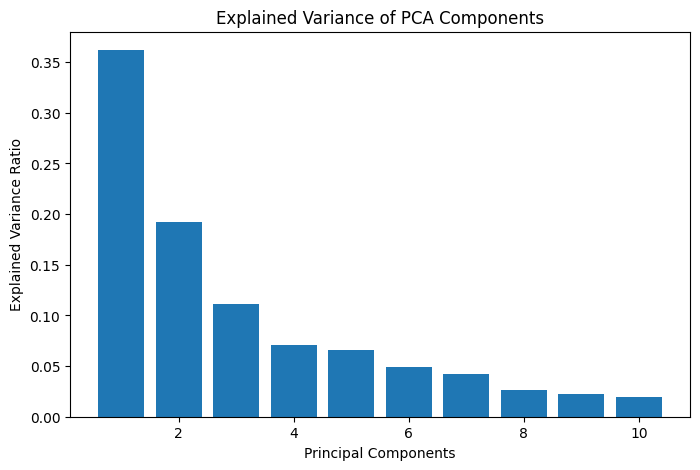

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Wine dataset
wine = datasets.load_wine()
X = wine.data  # Features
y = wine.target  # Target 

# Standardize dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA 
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Explained variance by each principal component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance of PCA Components")
plt.show()


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize models
log_reg = LogisticRegression()
nb = GaussianNB()
dt = DecisionTreeClassifier()

# Train models
log_reg.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predict
y_pred_log = log_reg.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_dt = dt.predict(X_test)

# Compute probabilities for AUC-ROC
y_prob_log = log_reg.predict_proba(X_test)
y_prob_nb = nb.predict_proba(X_test)
y_prob_dt = dt.predict_proba(X_test)



--- Logistic Regression Performance ---
Accuracy: 0.9722
Precision: 0.9741
Recall: 0.9722
F1 Score: 0.9720
AUC-ROC Score: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



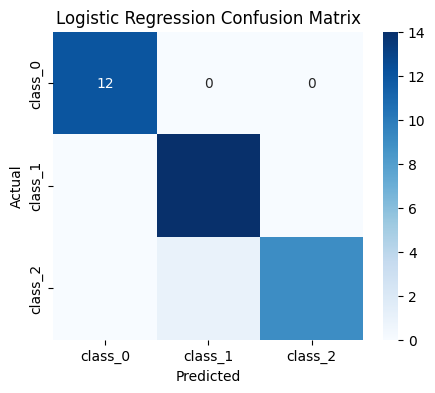


--- Naive Bayes Performance ---
Accuracy: 0.9722
Precision: 0.9741
Recall: 0.9722
F1 Score: 0.9720
AUC-ROC Score: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



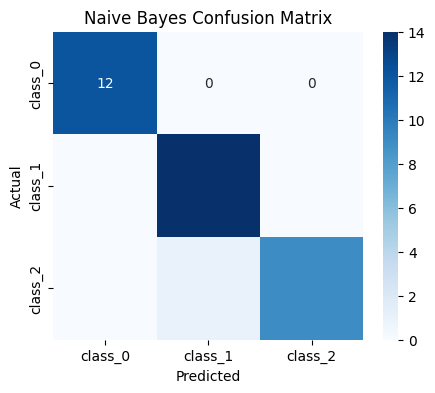


--- Decision Tree Performance ---
Accuracy: 0.9167
Precision: 0.9178
Recall: 0.9167
F1 Score: 0.9163
AUC-ROC Score: 0.9382

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87        12
           1       0.87      0.93      0.90        14
           2       1.00      1.00      1.00        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36



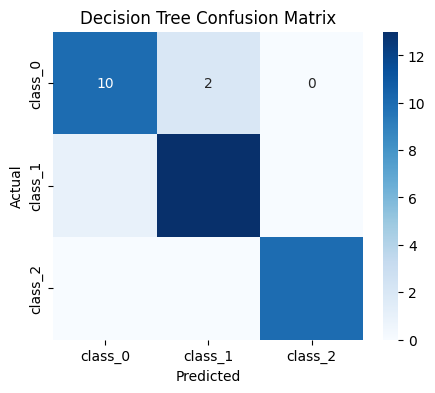

In [4]:
from sklearn.metrics import classification_report

def evaluate_model(y_true, y_pred, y_prob, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC Score: {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=wine.target_names, yticklabels=wine.target_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

# Evaluate 
evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, y_prob_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_dt, y_prob_dt, "Decision Tree")


In [5]:
from scipy.stats import f_oneway

# model errors
errors_log = np.abs(y_test - y_pred_log)
errors_nb = np.abs(y_test - y_pred_nb)
errors_dt = np.abs(y_test - y_pred_dt)

# F-test
f_stat, p_value = f_oneway(errors_log, errors_nb, errors_dt)
print(f"F-test Statistic: {f_stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in error variances (Reject Null Hypothesis).")
else:
    print("No significant difference in error variances (Fail to Reject Null Hypothesis).")


F-test Statistic: 0.8284, P-value: 0.4396
No significant difference in error variances (Fail to Reject Null Hypothesis).


In [6]:
from scipy.stats import ttest_ind

t_stat1, p_val1 = ttest_ind(errors_log, errors_nb)
t_stat2, p_val2 = ttest_ind(errors_log, errors_dt)
t_stat3, p_val3 = ttest_ind(errors_nb, errors_dt)

print("\nT-Test Results:")
print(f"Logistic Regression vs Naive Bayes: t = {t_stat1:.4f}, p = {p_val1:.4f}")
print(f"Logistic Regression vs Decision Tree: t = {t_stat2:.4f}, p = {p_val2:.4f}")
print(f"Naive Bayes vs Decision Tree: t = {t_stat3:.4f}, p = {p_val3:.4f}")



T-Test Results:
Logistic Regression vs Naive Bayes: t = 0.0000, p = 1.0000
Logistic Regression vs Decision Tree: t = -1.0221, p = 0.3102
Naive Bayes vs Decision Tree: t = -1.0221, p = 0.3102
